# Neural Surrogate Pretrain — Artifact Producer for NB09

Owns Bayesian.md §3.4.1 Steps 1-2: simulate the ground-truth panel,
derive the env state-space bounds from the panel, train the SHAC NN
surrogate over the joint (state × β) space, and persist a four-file
artifact bundle that [`09b_neural_surrogate_bayesian.ipynb`](09b_neural_surrogate_bayesian.ipynb)
consumes for Steps 3-4 (MCMC + validation).

This split eliminates inline NN retraining inside the MCMC notebook and
makes the NN a versioned artifact rather than a notebook side-effect. The
bundle (weights + normalizer + panel + metadata) is the integration
contract between this notebook and NB09; no other cross-notebook state
is required.

## Output files

Saved under `outputs/notebooks/09a_neural_surrogate_pretrain/`:

| File | Content |
|---|---|
| `shac_full_frictionless.weights.h5` | Keras weights of the SHAC NN |
| `shac_full_frictionless.weights.h5.normalizer.npz` | StaticNormalizer mean / std (sidecar) |
| `shac_full_frictionless.panel.npz` | Clean panel: `k` (N, T+1), `z` (N, T+1), sized for the FULL profile |
| `shac_full_frictionless.meta.json` | Training + env + β-sampler config, ground-truth β, master seed, best-step, best-MAE, train wall |

## Workflow

1. Generate panel (closed-form, env-less).
2. Derive env bounds from the panel.
3. Build `ParameterizedBasicInvestmentEnv` with explicit bounds.
4. Train SHAC over (state × β); cache to disk; reuse on re-run.
5. Slope diagnostic + comparative-statics visual validation.
6. Save the four-file bundle.

## Reproducibility

All randomness flows from one `MASTER_SEED` pair via `fold_in_seed`:

```
MASTER_SEED
├── fold_in_seed(MASTER, "panel", "z0"/"eps"/"obs_noise_y")   panel
└── fold_in_seed(MASTER, "train")                            NN training
```

The NN cache key is also seeded; a different `MASTER_SEED` forces a fresh training run.

---
# Section 0: Setup

In [1]:
from pathlib import Path
import hashlib
import json
import os
import sys
import time
import warnings

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")
warnings.filterwarnings("ignore", message=r".*does not produce the same series as CPU implementation.*")
warnings.filterwarnings("ignore", message=r".*casting an input of type complex64.*")

_nb_file = globals().get("__vsc_ipynb_file__")
_REPO_ROOT = Path(_nb_file).parent.parent if _nb_file else Path.cwd().parent
if str(_REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(_REPO_ROOT))

import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt

# CPU only by default. TF stateless RNG is bit-identical on CPU but not on
# Metal/GPU, which would violate the Bayesian.md §2.9 reproducibility claim.
USE_GPU = False
import tensorflow as tf
if not USE_GPU:
    tf.config.set_visible_devices([], "GPU")
tf.get_logger().setLevel("ERROR")

from src.v2.environments.basic_investment import EconomicParams, ShockParams
from src.v2.environments.parameterized_basic_investment import (
    ParameterizedBasicInvestmentEnv,
)
from src.v2.estimation.bayesian_neural_basic_investment import (
    derive_env_bounds_from_panel,
    diagnose_nn_linear_slope,
    generate_frictionless_panel,
    save_policy_with_normalizer,
)
from src.v2.estimation.beta_sampler import (
    BETA_DIM_NAMES, BetaSampler, DEFAULT_UNIFORM_BOUNDS,
)
from src.v2.networks.policy import ParameterizedPolicyNetwork
from src.v2.evaluation.policies import restore_selected_snapshot
from src.v2.networks.state_value import ParameterizedStateValueNetwork
from src.v2.trainers.config import (
    SHACConfig, NetworkConfig, OptimizerConfig,
)
from src.v2.trainers.shac_param import train_shac_param
from src.v2.utils.seeding import fold_in_seed

print(f"tf: {tf.__version__}")
print(f"logical devices: {[d.device_type for d in tf.config.list_logical_devices()]}")
np.set_printoptions(precision=4, suppress=True)

/Users/wangzhaoxuan/Desktop/JPM-TSRL/DL_corp_finance/.venv/lib/python3.12/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


tf: 2.16.2
logical devices: ['CPU']


---
# Section 1: Config, ground-truth panel, output dir

Profile (always FULL here — pretrain is a one-time job), master seed, calibrated
and ground-truth parameters; then synthesize the panel under the closed-form
analytical policy (no env required yet).

In [2]:
# Pretrain always runs at FULL spec: the NN is amortized over the prior
# support of β, and the panel is sized for the largest downstream consumer
# (NB09 FULL profile: N=200, T=40). Smaller NB09 profiles will slice this
# panel.
P = dict(
    description=("FULL pretrain: N=200 firms, T=40 periods; "
                 "SHAC 8000 steps, n_train=65536, n_critic=16, plateau_patience=16. "
                 "Wall time approximately 60-90 min on CPU (one-time, cached)."),
    # Panel (sized for FULL consumer)
    n_firms=200, horizon=40, burn_in=30,
    # NN architecture
    nn_n_layers=4, nn_n_neurons=256,
    # SHAC training (uplifted from prior NB09 defaults per the plan)
    n_train=65536, batch_size=256, shac_steps=8000, n_critic=16,
    plateau_patience=16,
)
print(f"{P['description']}")

MASTER_SEED = (20, 26)

# Calibrated (fixed, never inferred)
INTEREST_RATE     = 0.04
DEPRECIATION_RATE = 0.10
MU                = 0.0

# Ground-truth structural β to recover (downstream in NB09)
TRUE_ALPHA   = 0.5
TRUE_RHO     = 0.5
TRUE_SIG_EPS = 0.24
TRUE_SIG_ETA = 0.05   # exogenous, measurement noise on revenue
TRUE_SIG_XI  = 0.01   # exogenous, data-gen value; posterior tells us NN error

# Output directory: notebook-owned. Stable path consumed by NB09.
OUTPUT_DIR = _REPO_ROOT / "outputs" / "notebooks" / "09a_neural_surrogate_pretrain"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"OUTPUT_DIR = {OUTPUT_DIR}")

FULL pretrain: N=200 firms, T=40 periods; SHAC 8000 steps, n_train=65536, n_critic=16, plateau_patience=16. Wall time approximately 60-90 min on CPU (one-time, cached).
OUTPUT_DIR = /Users/wangzhaoxuan/Desktop/JPM-TSRL/DL_corp_finance/outputs/notebooks/09_neural_surrogate_pretrain


In [3]:
# Section 1: synthesize the ground-truth panel (closed-form, env-less).
#
# The frictionless analytical policy + AR(1) on log z is pure math, no env
# instance needed. This means we can derive env bounds from the panel
# afterwards, instead of having to pick multipliers ahead of time.
#
# Panel is sized for the FULL NB09 profile (horizon+1 to allow log_k_next
# slicing). NB09 slices the panel per profile.

beta_true = {
    "alpha":         TRUE_ALPHA,
    "rho":           TRUE_RHO,
    "sigma_epsilon": TRUE_SIG_EPS,
    "sigma_eta":     TRUE_SIG_ETA,
    "sigma_xi":      TRUE_SIG_XI,
}

panel = generate_frictionless_panel(
    beta=beta_true,
    interest_rate=INTEREST_RATE,
    depreciation_rate=DEPRECIATION_RATE,
    mu=MU,
    n_firms=P["n_firms"], horizon=P["horizon"] + 1, burn_in=P["burn_in"],
    seed=fold_in_seed(MASTER_SEED, "panel"),
)
print(f"panel shapes: k={panel['k'].shape}, z={panel['z'].shape}")
print(f"k range: [{panel['k'].min():.3f}, {panel['k'].max():.3f}]")
print(f"z range: [{panel['z'].min():.3f}, {panel['z'].max():.3f}]")
print(f"  log z mean ≈ {np.mean(np.log(panel['z'])):.3f},  sd ≈ {np.std(np.log(panel['z'])):.3f}")
analytical_sd = TRUE_SIG_EPS / np.sqrt(1 - TRUE_RHO**2)
print(f"  analytical stationary log-z sd = {analytical_sd:.3f}")

panel shapes: k=(200, 41), z=(200, 41)
k range: [4.702, 37.985]
z range: [0.348, 2.811]
  log z mean ≈ 0.005,  sd ≈ 0.276
  analytical stationary log-z sd = 0.277


---
# Section 2: Derive env bounds and build the env

k bounds from the observed panel (plus a small margin); z bounds from a fixed
log-z half-width chosen to keep SHAC training in a non-clipped action region
(see NB09 cell `7b9db34f` for the rationale).

In [4]:
# z bounds: FIXED log-z half-width (not derived from panel's latent z,
# not from the prior worst case). log_z_half_width=1.0 mirrors NB08's
# default z box (where SHAC achieves <2% held-out MAE of the k range).
# Wider z would put the NN's training in clipped territory and degrade
# SHAC's gradient signal; the EKF's m_pred during MCMC stays in [-1, 1]
# anyway because the Kalman gain pulls it toward the data.
bounds = derive_env_bounds_from_panel(
    panel["k"],
    k_margin=1.2,
    log_z_half_width=1.0,
    mu=MU,
)
print("Derived env bounds:")
for k, v in bounds.items():
    print(f"  {k:6s} = {v:.4f}")

nominal_econ = EconomicParams(
    interest_rate=INTEREST_RATE, depreciation_rate=DEPRECIATION_RATE,
    production_elasticity=TRUE_ALPHA, cost_convex=0.0, cost_fixed=0.0,
)
nominal_shocks = ShockParams(rho=TRUE_RHO, sigma=TRUE_SIG_EPS, mu=MU)
param_env = ParameterizedBasicInvestmentEnv(
    nominal_econ=nominal_econ,
    nominal_shocks=nominal_shocks,
    bounds=bounds,
)
beta_sampler = BetaSampler(freeze_dims=(3, 4))
anchor_beta = beta_sampler.prior_mean()
print(f"env.k_star (nominal β, for diagnostics) = {param_env.k_star:.4f}")
print(f"env state-space box = ({param_env.k_min:.3f}, {param_env.k_max:.3f}) "
      f"x ({param_env.z_min:.3f}, {param_env.z_max:.3f})")
print(f"BetaSampler uniform_bounds = {beta_sampler.uniform_bounds}")
print(f"anchor β (prior-mean, frictionless slice) = {anchor_beta.numpy().ravel()}")

Derived env bounds:
  k_min  = 3.9181
  k_max  = 45.5824
  z_min  = 0.3679
  z_max  = 2.7183
env.k_star (nominal β, for diagnostics) = 13.5114
env state-space box = (3.918, 45.582) x (0.368, 2.718)
BetaSampler uniform_bounds = ((0.2, 0.85), (0.1, 0.9), (0.05, 0.6), (0.0, 1.5), (0.0, 0.15))
anchor β (prior-mean, frictionless slice) = [0.525 0.5   0.325 0.    0.   ]


---
# Section 3: Train NN surrogate (with held-out MAE validation + cache)

Mirrors the validated SHAC training workflow from NB08, with config uplifted
per the plan (n_train=65536, n_critic=16, shac_steps=8000, plateau_patience=16)
to address the prior 18% single-point slope error observed at the smaller spec.

- **Held-out validation set**: fixed `(s_endo, z, β)` tuples sampled
  uniformly from the env. The eval callback compares the policy's
  predicted `k'` against `env.analytical_kprime`.
- **Checkpoint history** + **plateau early-stop** + **best-step
  restore**: the trainer captures policy weights at every eval interval;
  after training we load weights from the step that minimized the
  held-out MAE.
- **Hard MAE gate**: after best-step restore, we require held-out MAE
  below 2% of the k range. If the gate fails we abort rather than feed
  a poor NN into the downstream bundle.
- **Cache**: SHAC weights + normalizer are saved to `OUTPUT_DIR` keyed by
  `(seed, bounds, NN architecture, training config)`. Re-running the
  cell with the same config skips training.

In [5]:
# ---- Cache key & paths --------------------------------------------------
def _cache_key(seed, bounds, n_layers, n_neurons,
               n_train, batch_size, shac_steps, n_critic, plateau_patience):
    payload = json.dumps({
        "seed":              list(seed),
        "bounds":            {k: float(v) for k, v in bounds.items()},
        "n_layers":          int(n_layers),
        "n_neurons":         int(n_neurons),
        "n_train":           int(n_train),
        "batch_size":        int(batch_size),
        "shac_steps":        int(shac_steps),
        "n_critic":          int(n_critic),
        "plateau_patience":  int(plateau_patience),
    }, sort_keys=True)
    return hashlib.sha1(payload.encode()).hexdigest()[:12]

CACHE_KEY = _cache_key(MASTER_SEED, bounds,
                       P["nn_n_layers"], P["nn_n_neurons"],
                       P["n_train"], P["batch_size"], P["shac_steps"],
                       P["n_critic"], P["plateau_patience"])
NN_WEIGHTS  = OUTPUT_DIR / f"nn_weights_{CACHE_KEY}.weights.h5"
NN_METADATA = OUTPUT_DIR / f"nn_metadata_{CACHE_KEY}.json"

# ---- Held-out validation set (fixed once) -------------------------------
N_VAL = 1024
val_s_endo = param_env.sample_initial_endogenous(
    N_VAL, seed=tf.constant(fold_in_seed(MASTER_SEED, "train", "val", "s_endo"), tf.int32))
val_z      = param_env.sample_initial_exogenous(
    N_VAL, seed=tf.constant(fold_in_seed(MASTER_SEED, "train", "val", "z"), tf.int32))
val_beta   = beta_sampler.sample(
    N_VAL, seed=fold_in_seed(MASTER_SEED, "train", "val", "beta"))
val_dataset = {"s_endo": val_s_endo, "z": val_z, "beta": val_beta}

def _make_holdout_mae_callback():
    s_all   = param_env.merge_state(val_dataset["s_endo"], val_dataset["z"])
    k_all   = val_dataset["s_endo"][:, 0].numpy()
    kp_true = param_env.analytical_kprime(
        val_dataset["z"], val_dataset["beta"]).numpy().ravel()
    def cb(step, env, policy, value_net, val_dataset):
        a = policy(s_all, val_dataset["beta"]).numpy().ravel()
        kp_pred = np.clip(
            (1.0 - env.delta_rate) * k_all + a, env.k_min, env.k_max)
        return {"mae_holdout": float(np.mean(np.abs(kp_pred - kp_true)))}
    return cb

# ---- Build policy + (for SHAC) value network ----------------------------
policy_nn = ParameterizedPolicyNetwork(
    state_dim=param_env.state_dim(), action_dim=param_env.action_dim(), beta_dim=5,
    **param_env.action_spec(),
    n_layers=P["nn_n_layers"], n_neurons=P["nn_n_neurons"],
    seed=(202, 0),
)
policy_nn(tf.zeros((1, param_env.state_dim())), tf.zeros((1, 5)))

if NN_WEIGHTS.exists() and NN_METADATA.exists():
    from src.v2.estimation.bayesian_neural_basic_investment import load_policy_with_normalizer
    load_policy_with_normalizer(policy_nn, NN_WEIGHTS)
    _meta = json.loads(NN_METADATA.read_text())
    print(f"Loaded cached NN: {NN_WEIGHTS}")
    print(f"  cache key  = {CACHE_KEY}")
    print(f"  train wall = {_meta.get('train_wall_sec', '?'):.1f}s, "
          f"best_step = {_meta.get('best_step')}, "
          f"best_mae = {_meta.get('best_mae'):.4f}")
    train_wall = float(_meta.get("train_wall_sec", 0.0))
    best_step  = int(_meta.get("best_step", 0))
    best_mae   = float(_meta.get("best_mae", 0.0))
    stop_reason = _meta.get("stop_reason", "cached")
else:
    print(f"Cache miss (key {CACHE_KEY}). Training SHAC inline (60-90 min CPU)...")
    value_nn = ParameterizedStateValueNetwork(
        state_dim=param_env.state_dim(), beta_dim=5,
        n_layers=P["nn_n_layers"], n_neurons=P["nn_n_neurons"],
        seed=(203, 0),
    )
    value_nn(tf.zeros((1, param_env.state_dim())), tf.zeros((1, 5)))

    train_seed = fold_in_seed(MASTER_SEED, "train")
    train_dataset = {
        "s_endo": param_env.sample_initial_endogenous(
            P["n_train"], seed=tf.constant(train_seed, tf.int32)),
        "z":      param_env.sample_initial_exogenous(
            P["n_train"], seed=tf.constant(fold_in_seed(train_seed, "z0"), tf.int32)),
    }

    shac_ckpt = []
    shac_config = SHACConfig(
        n_steps=P["shac_steps"], batch_size=P["batch_size"],
        horizon=64, short_horizon=16, n_critic=P["n_critic"],
        eval_interval=50, master_seed=tuple(train_seed),
        normalize_rewards=False, reward_scale_override=0.05,
        network=NetworkConfig(n_layers=P["nn_n_layers"], n_neurons=P["nn_n_neurons"]),
        policy_optimizer=OptimizerConfig(learning_rate=2e-3),
        critic_optimizer=OptimizerConfig(learning_rate=5e-3),
        checkpoint_history=shac_ckpt,
        snapshot_targets=("policy",),
        monitor="mae_holdout", mode="min",
        plateau_patience=P["plateau_patience"], plateau_rel_delta=0.02,
        min_steps_before_stop=300,
    )
    _t0 = time.time()
    result_shac = train_shac_param(
        param_env, policy_nn, value_nn, beta_sampler, train_dataset,
        val_dataset=val_dataset, config=shac_config,
        eval_callback=_make_holdout_mae_callback(),
    )
    train_wall = time.time() - _t0
    print(f"Training wall: {train_wall:.1f}s   "
          f"stop_reason = {result_shac.get('stop_reason', 'max_steps')}")

    history = result_shac["history"]
    steps   = history["step"]
    maes    = history["mae_holdout"]
    best_i  = int(np.argmin(maes))
    best_step = int(steps[best_i])
    best_mae  = float(maes[best_i])
    final_mae = float(maes[-1])
    restore_selected_snapshot(policy_nn, shac_ckpt, best_step)
    print(f"Best step = {best_step} (mae_holdout = {best_mae:.4f}) | "
          f"final = {int(steps[-1])} (mae = {final_mae:.4f}) | "
          f"gap = {100*(final_mae-best_mae)/max(best_mae,1e-8):.1f}%")

    save_policy_with_normalizer(policy_nn, NN_WEIGHTS)
    stop_reason = result_shac.get("stop_reason", "max_steps")
    NN_METADATA.write_text(json.dumps({
        "cache_key":       CACHE_KEY,
        "master_seed":     list(MASTER_SEED),
        "bounds":          {k: float(v) for k, v in bounds.items()},
        "nn_architecture": {"n_layers": P["nn_n_layers"], "n_neurons": P["nn_n_neurons"]},
        "training_config": {"n_train": P["n_train"], "batch_size": P["batch_size"],
                            "shac_steps": P["shac_steps"], "n_critic": P["n_critic"],
                            "plateau_patience": P["plateau_patience"]},
        "best_step":       best_step,
        "best_mae":        best_mae,
        "final_mae":       final_mae,
        "train_wall_sec":  float(train_wall),
        "stop_reason":     stop_reason,
    }, indent=2))
    print(f"Saved weights + normalizer + metadata to {OUTPUT_DIR}")

policy_nn.trainable = False

# ---- Hard MAE gate ------------------------------------------------------
cb = _make_holdout_mae_callback()
final_mae_check = cb(0, param_env, policy_nn, None, val_dataset)["mae_holdout"]
k_range = param_env.k_max - param_env.k_min
mae_pct = 100.0 * final_mae_check / k_range
print(f"\nHeld-out MAE after best-step restore: {final_mae_check:.4f} "
      f"({mae_pct:.2f}% of k range = {k_range:.2f})")
MAE_GATE = 0.02 * k_range
if final_mae_check > MAE_GATE:
    raise RuntimeError(
        f"NN surrogate is not accurate enough: held-out MAE {final_mae_check:.4f} "
        f"({mae_pct:.2f}% of k_range = {k_range:.2f}) exceeds gate "
        f"{MAE_GATE:.4f} ({100*MAE_GATE/k_range:.2f}%). "
        "Increase shac_steps, n_train, n_critic, or NN size.")
print(f"NN surrogate passes MAE gate (< {100*MAE_GATE/k_range:.2f}% of k range).")

Cache miss (key 3a4a613afaaf). Training SHAC inline (60-90 min CPU)...
SHAC-param step     0 | loss_actor=-2.9779 | loss_critic=0.012575 | elapsed=6.1s
SHAC-param step    50 | loss_actor=-4.1220 | loss_critic=0.000791 | elapsed=37.6s
SHAC-param step   100 | loss_actor=-4.7155 | loss_critic=0.006851 | elapsed=68.4s
SHAC-param step   150 | loss_actor=-4.6473 | loss_critic=0.007960 | elapsed=99.9s
SHAC-param step   200 | loss_actor=-4.6046 | loss_critic=0.008033 | elapsed=132.0s
SHAC-param step   250 | loss_actor=-4.8369 | loss_critic=0.013081 | elapsed=164.1s
SHAC-param step   300 | loss_actor=-5.1707 | loss_critic=0.062878 | elapsed=197.6s
SHAC-param step   350 | loss_actor=-4.4098 | loss_critic=0.009459 | elapsed=232.2s
SHAC-param step   400 | loss_actor=-5.3645 | loss_critic=0.016879 | elapsed=265.5s
SHAC-param step   450 | loss_actor=-5.1927 | loss_critic=0.031830 | elapsed=297.8s
SHAC-param step   500 | loss_actor=-5.0934 | loss_critic=0.040093 | elapsed=330.3s
SHAC-param step   550

---
# Section 4: NN linearization sanity check

Probe the NN's slope of `log k'` vs `log z` at the ground-truth β. The
closed-form reference is `ρ/(1-α)` (Bayesian.md §2.2).

This single-point slope is **informational**, not a hard gate. The
σ_ξ posterior in NB09 is the authoritative in-line readout of NN error;
the slope here is a quick visual check at one anchor point.

In [6]:
diag = diagnose_nn_linear_slope(param_env, policy_nn, beta_true)
print("NN linearization diagnostic at ground-truth β:")
for k, v in diag.items():
    print(f"  {k:25s} = {v:.4f}")
print(f"\nNN slope relative error vs analytical: {100*diag['rel_error']:.2f}%.")
print("(Informational; σ_ξ posterior in NB09 is the authoritative NN-error diagnostic.)")

NN linearization diagnostic at ground-truth β:
  slope_nn                  = 0.9130
  slope_analytical          = 1.0000
  rel_error                 = 0.0870
  intercept_nn              = 2.6280
  intercept_analytical      = 2.6035

NN slope relative error vs analytical: 8.70%.
(Informational; σ_ξ posterior in NB09 is the authoritative NN-error diagnostic.)


---
# Section 5: Comparative-statics visual validation

1-D sweeps of the SHAC NN's predicted `k'` against the analytical reference
along (α, ρ, σ_ε, z, k). All sweeps hold the other coordinates at the
prior-mean anchor β (frictionless slice). Helpful for visually spotting where
the NN deviates from the closed-form before NB09 consumes the bundle.

In [7]:
def _kprime_from_policy(policy, s, beta):
    """Action I → next capital k' = (1-δ)k + I (clipped to bounds)."""
    a = policy(s, beta).numpy().ravel()
    k = s.numpy()[:, 0]
    return np.clip((1.0 - param_env.delta_rate) * k + a, param_env.k_min, param_env.k_max)

def _kprime_analytical(s, beta):
    return param_env.analytical_kprime(s[:, 1:2], beta).numpy().ravel()

def _sweep(param_idx, grid, fixed_state, anchor_beta_1d, n_grid=80):
    """Sweep one parameter index over `grid`; broadcast s and anchor β."""
    beta = np.tile(anchor_beta_1d, (n_grid, 1)).astype(np.float32)
    beta[:, param_idx] = grid
    beta_tf = tf.constant(beta)
    s = tf.constant(np.tile(fixed_state, (n_grid, 1)).astype(np.float32))
    return s, beta_tf

fixed_state = np.array([param_env.k_star, float(np.exp(param_env.mu))])
anchor_1d   = anchor_beta.numpy().ravel()
print("fixed state =", fixed_state)
print("anchor β    =", anchor_1d)

fixed state = [13.5114  1.    ]
anchor β    = [0.525 0.5   0.325 0.    0.   ]


In [8]:
n_grid = 100

# For ρ we deliberately use z = 1.5·exp(μ) (above the singular point
# z = exp(μ) where ρ has no analytical effect). Other slices stay at
# the conventional (k*, E[z]) anchor.
anchor_rho_state = np.array([param_env.k_star, 1.5 * float(np.exp(param_env.mu))],
                            dtype=np.float32)

alpha_lo, alpha_hi = DEFAULT_UNIFORM_BOUNDS["alpha"]
rho_lo,   rho_hi   = DEFAULT_UNIFORM_BOUNDS["rho"]
sig_lo,   sig_hi   = DEFAULT_UNIFORM_BOUNDS["sigma_epsilon"]

sweeps = {
    "alpha":         (0, np.linspace(alpha_lo, alpha_hi, n_grid), fixed_state),
    "rho":           (1, np.linspace(rho_lo,   rho_hi,   n_grid), anchor_rho_state),
    "sigma_epsilon": (2, np.linspace(sig_lo,   sig_hi,   n_grid), fixed_state),
}

results = {}
for name, (idx, grid, fixed_s) in sweeps.items():
    s_in, beta_in = _sweep(idx, grid.astype(np.float32), fixed_s, anchor_1d, n_grid=n_grid)
    kp_shac = _kprime_from_policy(policy_nn, s_in, beta_in)
    kp_true = _kprime_analytical(s_in, beta_in)
    results[name] = {
        "grid": grid, "shac": kp_shac, "true": kp_true,
        "mae_shac": float(np.mean(np.abs(kp_shac - kp_true))),
        "anchor":   fixed_s.tolist(),
        "xrange":   (grid.min(), grid.max()),
    }
for name, r in results.items():
    print(f"{name:15s}  anchor=(k={r['anchor'][0]:.2f}, z={r['anchor'][1]:.2f})  "
          f"MAE_SHAC={r['mae_shac']:.4f}")

alpha            anchor=(k=13.51, z=1.00)  MAE_SHAC=0.2114
rho              anchor=(k=13.51, z=1.50)  MAE_SHAC=0.9347
sigma_epsilon    anchor=(k=13.51, z=1.00)  MAE_SHAC=0.3878


In [9]:
# z spans full env support; k spans full env support.
# Analytical k'(z;β) is independent of k in the frictionless model, so the
# k-slice should be flat.
z_grid = np.linspace(param_env.z_min, param_env.z_max, n_grid).astype(np.float32)
s_z = tf.constant(np.stack(
    [np.full(n_grid, param_env.k_star, dtype=np.float32), z_grid], axis=-1))
beta_z = tf.constant(np.tile(anchor_1d, (n_grid, 1)).astype(np.float32))
kp_shac_z = _kprime_from_policy(policy_nn, s_z, beta_z)
kp_true_z = _kprime_analytical(s_z, beta_z)
results["z (anchor β)"] = {
    "grid": z_grid, "shac": kp_shac_z, "true": kp_true_z,
    "mae_shac": float(np.mean(np.abs(kp_shac_z - kp_true_z))),
    "xrange":   (param_env.z_min, param_env.z_max),
}

k_grid = np.linspace(param_env.k_min, param_env.k_max, n_grid).astype(np.float32)
z_anchor = float(np.exp(param_env.mu))
s_k = tf.constant(np.stack(
    [k_grid, np.full(n_grid, z_anchor, dtype=np.float32)], axis=-1))
beta_k = tf.constant(np.tile(anchor_1d, (n_grid, 1)).astype(np.float32))
kp_shac_k = _kprime_from_policy(policy_nn, s_k, beta_k)
kp_true_k = _kprime_analytical(s_k, beta_k)
results["k (anchor β)"] = {
    "grid": k_grid, "shac": kp_shac_k, "true": kp_true_k,
    "mae_shac": float(np.mean(np.abs(kp_shac_k - kp_true_k))),
    "xrange":   (param_env.k_min, param_env.k_max),
}
for name in ["z (anchor β)", "k (anchor β)"]:
    r = results[name]
    print(f"{name:18s}  MAE_SHAC={r['mae_shac']:.4f}")

z (anchor β)        MAE_SHAC=0.2243
k (anchor β)        MAE_SHAC=0.1250


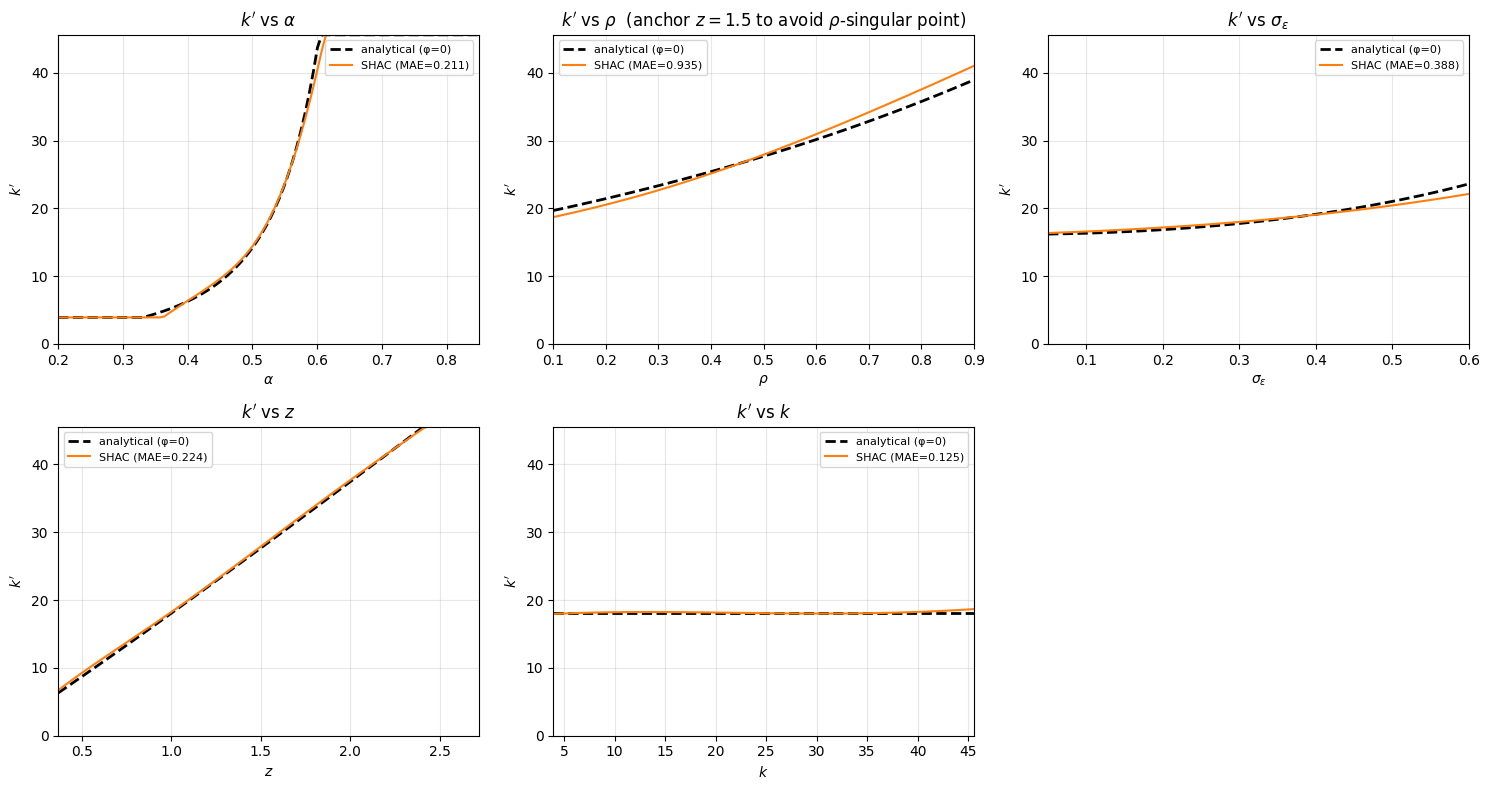

Saved comparative-statics figure to /Users/wangzhaoxuan/Desktop/JPM-TSRL/DL_corp_finance/outputs/notebooks/09_neural_surrogate_pretrain/slices_pretrain.png


In [10]:
slice_order = [
    "alpha", "rho", "sigma_epsilon",
    "z (anchor β)", "k (anchor β)",
]
xlabels = {
    "alpha": r"$\alpha$", "rho": r"$\rho$",
    "sigma_epsilon": r"$\sigma_\varepsilon$",
    "z (anchor β)": r"$z$",
    "k (anchor β)": r"$k$",
}
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()
for ax, name in zip(axes, slice_order):
    r = results[name]
    ax.plot(r["grid"], r["true"], 'k--', lw=2, label="analytical (φ=0)")
    ax.plot(r["grid"], r["shac"], 'C1',  lw=1.5,
            label=f"SHAC (MAE={r['mae_shac']:.3f})")
    ax.set_ylim(0, param_env.k_max)
    ax.set_xlim(*r['xrange'])
    ax.set_xlabel(xlabels[name]); ax.set_ylabel(r"$k'$")
    title = f"$k'$ vs {xlabels[name]}"
    if name == "rho":
        title += r"  (anchor $z = 1.5$ to avoid $\rho$-singular point)"
    ax.set_title(title)
    ax.legend(loc="best", fontsize=8)
    ax.grid(True, alpha=0.3)
axes[5].axis("off")
plt.tight_layout()
SLICE_PLOT_PATH = OUTPUT_DIR / "slices_pretrain.png"
fig.savefig(SLICE_PLOT_PATH, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved comparative-statics figure to {SLICE_PLOT_PATH}")

---
# Section 6: Save NN weights and biases for inference

Produces the four-file bundle described in the intro. The path
prefix is stable (`shac_full_frictionless`) so NB09 can hard-code
the location. The bundle is the integration contract; NB09 does
not need to know any other state from this notebook.

In [11]:
from dataclasses import asdict

BUNDLE_BASE = OUTPUT_DIR / "shac_full_frictionless"

# (a) NN weights + normalizer (uses the existing helper).
save_policy_with_normalizer(policy_nn, BUNDLE_BASE.with_suffix(".weights.h5"))

# (b) Clean panel (k, z arrays). NB09 overlays η measurement noise on its side.
np.savez(BUNDLE_BASE.with_suffix(".panel.npz"),
         k=panel["k"], z=panel["z"])

# (c) Metadata JSON: env config, training config, β config, ground-truth β,
#     master seed, NN training diagnostics. Everything NB09 needs to rebuild
#     env + spec + observations.
metadata = {
    "cache_key":         CACHE_KEY,
    "master_seed":       list(MASTER_SEED),
    "env": {
        "nominal_econ":    asdict(nominal_econ),
        "nominal_shocks":  asdict(nominal_shocks),
        "bounds":          {k: float(v) for k, v in bounds.items()},
        "interest_rate":   INTEREST_RATE,
        "depreciation_rate": DEPRECIATION_RATE,
        "mu":              MU,
    },
    "panel": {
        "n_firms":  int(P["n_firms"]),
        "horizon":  int(P["horizon"]),
        "burn_in":  int(P["burn_in"]),
    },
    "nn_architecture":   {"n_layers": P["nn_n_layers"], "n_neurons": P["nn_n_neurons"]},
    "training_config":   {
        "trainer":          "shac",
        "n_train":          P["n_train"],
        "batch_size":       P["batch_size"],
        "shac_steps":       P["shac_steps"],
        "n_critic":         P["n_critic"],
        "plateau_patience": P["plateau_patience"],
    },
    "beta_sampler":      {"freeze_dims": list(beta_sampler.freeze_dims)},
    "ground_truth_beta": dict(beta_true),
    "best_step":         int(best_step),
    "best_mae":          float(best_mae),
    "train_wall_sec":    float(train_wall),
    "stop_reason":       stop_reason,
}
BUNDLE_BASE.with_suffix(".meta.json").write_text(json.dumps(metadata, indent=2))

print(f"Saved bundle to:")
print(f"  {BUNDLE_BASE}.weights.h5")
print(f"  {BUNDLE_BASE}.weights.h5.normalizer.npz")
print(f"  {BUNDLE_BASE}.panel.npz")
print(f"  {BUNDLE_BASE}.meta.json")
print()
print("09b (docs/09b_neural_surrogate_bayesian.ipynb) loads this bundle directly.")

Saved bundle to:
  /Users/wangzhaoxuan/Desktop/JPM-TSRL/DL_corp_finance/outputs/notebooks/09_neural_surrogate_pretrain/shac_full_frictionless.weights.h5
  /Users/wangzhaoxuan/Desktop/JPM-TSRL/DL_corp_finance/outputs/notebooks/09_neural_surrogate_pretrain/shac_full_frictionless.weights.h5.normalizer.npz
  /Users/wangzhaoxuan/Desktop/JPM-TSRL/DL_corp_finance/outputs/notebooks/09_neural_surrogate_pretrain/shac_full_frictionless.panel.npz
  /Users/wangzhaoxuan/Desktop/JPM-TSRL/DL_corp_finance/outputs/notebooks/09_neural_surrogate_pretrain/shac_full_frictionless.meta.json

NB09 (docs/09_neural_surrogate_bayesian.ipynb) loads this bundle directly.
